# W1 Day 2 - Log Mining, Drain3 Parsing, and Anomaly Detection

Dataset: HDFS sample from Loghub (`data/HDFS_2k.log`).

## Phase 1 - 1. Import libraries

In [58]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
from drain3.masking import MaskingInstruction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DATA_DIR = Path('data')
RESULTS_DIR = Path('results')
PLOTS_DIR = Path('plots')
RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

## Phase 1 - 2. Load HDFS_2k.log

In [59]:
log_path = DATA_DIR / 'HDFS_2k.log'
lines = log_path.read_text(encoding='utf-8', errors='ignore').splitlines()
lines[:3]

['081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating',
 '081109 203807 222 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_-6952295868487656571 terminating',
 '081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864']

## Phase 1 - 3. Count total lines

In [60]:
total_lines = len(lines)
print(f'Total log lines: {total_lines}')

Total log lines: 2000


## Phase 1 - 4. Parse log with Drain3

In [61]:
def parse_hdfs_line(line):
    parts = line.strip().split(maxsplit=4)
    if len(parts) >= 5:
        timestamp = pd.to_datetime(parts[0] + parts[1], format='%y%m%d%H%M%S', errors='coerce')
        return timestamp, parts[4]
    return pd.NaT, line.strip()

def build_miner(sim_th=0.5):
    config = TemplateMinerConfig()
    config.drain_sim_th = sim_th
    config.drain_depth = 4
    config.profiling_enabled = False
    return TemplateMiner(config=config)

def parse_logs(lines, sim_th=0.5):
    miner = build_miner(sim_th)
    rows = []
    for raw_log in lines:
        timestamp, message = parse_hdfs_line(raw_log)
        result = miner.add_log_message(message)
        rows.append({
            'timestamp': timestamp,
            'raw_log': raw_log,
            'template_id': result['cluster_id'],
            'template': result['template_mined'],
        })
    parsed = pd.DataFrame(rows)
    final_templates = {cluster.cluster_id: cluster.get_template() for cluster in miner.drain.clusters}
    parsed['template'] = parsed.template_id.map(final_templates)
    return parsed, miner

parsed, miner = parse_logs(lines, sim_th=0.5)
print(f'Unique templates: {parsed.template_id.nunique()}')

Unique templates: 17


## Phase 1 - 5. Parsed logs table

In [62]:
parsed[['timestamp', 'raw_log', 'template_id', 'template']].head()

,timestamp,raw_log,template_id,template
0,2008-11-09 20:36:15,081109 203615 148 INFO dfs.DataNode$PacketResp...,1,dfs.DataNode$PacketResponder: PacketResponder ...
1,2008-11-09 20:38:07,081109 203807 222 INFO dfs.DataNode$PacketResp...,1,dfs.DataNode$PacketResponder: PacketResponder ...
2,2008-11-09 20:40:05,081109 204005 35 INFO dfs.FSNamesystem: BLOCK*...,2,dfs.FSNamesystem: BLOCK* NameSystem.addStoredB...
3,2008-11-09 20:40:15,081109 204015 308 INFO dfs.DataNode$PacketResp...,1,dfs.DataNode$PacketResponder: PacketResponder ...
4,2008-11-09 20:41:06,081109 204106 329 INFO dfs.DataNode$PacketResp...,1,dfs.DataNode$PacketResponder: PacketResponder ...


## Phase 1 - 6-7. Count templates and export top-10

In [63]:
top_templates = (parsed.groupby(['template_id', 'template']).size().reset_index(name='count')
                 .sort_values('count', ascending=False).head(10))
top_templates.to_csv(RESULTS_DIR / 'top_templates.csv', index=False)
print('Top 10 templates')
display(top_templates)

Top 10 templates


,template_id,template,count
1,2,dfs.FSNamesystem: BLOCK* NameSystem.addStoredB...,314
0,1,dfs.DataNode$PacketResponder: PacketResponder ...,311
2,3,dfs.DataNode$PacketResponder: Received block <...,292
3,4,dfs.DataNode$DataXceiver: Receiving block <*> ...,292
6,7,dfs.FSDataset: Deleting block <*> file <*>,263
9,10,dfs.FSNamesystem: BLOCK* NameSystem.delete: <*...,224
4,5,dfs.FSNamesystem: BLOCK* NameSystem.allocateBl...,115
8,9,dfs.DataNode$DataXceiver: <*> exception while ...,80
7,8,dfs.DataNode$DataXceiver: <*> Served block <*>...,80
5,6,dfs.DataBlockScanner: Verification succeeded f...,20


## Phase 1 - 8. Tune sim_th

In [64]:
tuning_rows = []
for sim_th in [0.3, 0.5, 0.7]:
    tuned, _ = parse_logs(lines, sim_th=sim_th)
    tuning_rows.append({'sim_th': sim_th, 'unique_templates': tuned.template_id.nunique()})
tuning_results = pd.DataFrame(tuning_rows)
tuning_results['note'] = ['merge more / fewer templates', 'balanced choice', 'split more / more templates']
tuning_results.to_csv(RESULTS_DIR / 'tuning_results.csv', index=False)
print('Tuning result table')
display(tuning_results)

Tuning result table


,sim_th,unique_templates,note
0,0.3,17,merge more / fewer templates
1,0.5,17,balanced choice
2,0.7,681,split more / more templates


## Phase 2 - Template count time series and 3-sigma anomaly

In [65]:
template_ts = (parsed.dropna(subset=['timestamp'])
               .groupby([pd.Grouper(key='timestamp', freq='5min'), 'template_id'])
               .size().unstack(fill_value=0).sort_index())

spike_rows = []
for template_id in template_ts.columns:
    series = template_ts[template_id].astype(float)
    mean = series.mean()
    std = series.std(ddof=0)
    z = (series - mean) / std if std > 0 else pd.Series(0, index=series.index)
    for spike_time, z_score in z[z >= 3].items():
        spike_rows.append({
            'template_id': template_id,
            'template': parsed.loc[parsed.template_id == template_id, 'template'].iloc[0],
            'spike_time': spike_time,
            'count_5min': int(series.loc[spike_time]),
            'mean_5min': round(mean, 2),
            'z_score': round(z_score, 2),
            'rule': '3-sigma',
        })

spikes = pd.DataFrame(spike_rows).sort_values('z_score', ascending=False)
spikes.to_csv(RESULTS_DIR / 'template_spikes.csv', index=False)
print('Template n?o spike')
display(spikes.head())

Template n?o spike


,template_id,template,spike_time,count_5min,mean_5min,z_score,rule
76,17,dfs.FSNamesystem: BLOCK* ask 10.251.126.5:5001...,2008-11-11 09:15:00,1,0.0,17.44,3-sigma
68,11,dfs.DataNode: 10.250.15.198:50010 Starting thr...,2008-11-10 21:15:00,1,0.0,17.44,3-sigma
75,16,dfs.FSNamesystem: BLOCK* ask 10.250.14.38:5001...,2008-11-11 08:05:00,1,0.0,17.44,3-sigma
74,15,dfs.FSNamesystem: BLOCK* ask 10.250.10.213:500...,2008-11-11 06:50:00,1,0.0,17.44,3-sigma
73,14,dfs.FSNamesystem: BLOCK* ask 10.250.17.177:500...,2008-11-11 06:50:00,1,0.0,17.44,3-sigma


## Phase 2 - Plot anomaly highlighted

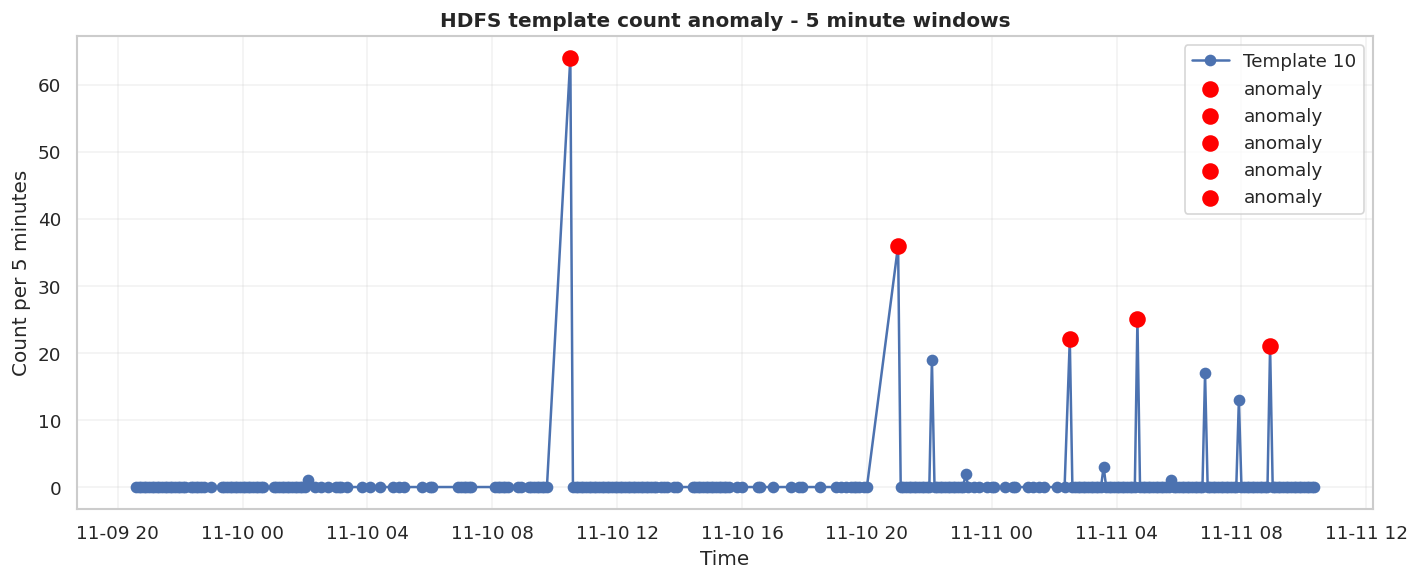

In [66]:
meaningful_spikes = spikes[spikes['count_5min'] >= 5]
plot_template_id = int((meaningful_spikes if not meaningful_spikes.empty else spikes).iloc[0].template_id)
series = template_ts[plot_template_id]
plt.figure(figsize=(12, 5))
plt.plot(series.index, series.values, marker='o', label=f'Template {plot_template_id}')
for row in spikes[(spikes.template_id == plot_template_id) & (spikes.count_5min >= 5)].head(5).itertuples(index=False):
    plt.scatter(pd.to_datetime(row.spike_time), row.count_5min, color='red', s=80, zorder=5, label='anomaly')
plt.title('HDFS template count anomaly - 5 minute windows')
plt.xlabel('Time')
plt.ylabel('Count per 5 minutes')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'template_count_anomaly.png', dpi=160)
plt.show()

## Phase 3 - TF-IDF template similarity

In [67]:
templates = top_templates.template.tolist()
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(templates)
similarity = cosine_similarity(tfidf)

pairs = []
for i in range(len(templates)):
    for j in range(i + 1, len(templates)):
        pairs.append((similarity[i, j], templates[i], templates[j]))

for score, left, right in sorted(pairs, reverse=True)[:5]:
    print(f'similarity={score:.3f}')
    print('A:', left)
    print('B:', right)
    print()

similarity=0.509
A: dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
B: dfs.FSNamesystem: BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>

similarity=0.427
A: dfs.DataNode$DataXceiver: <*> exception while serving <*> to <*>
B: dfs.DataNode$DataXceiver: <*> Served block <*> to <*>

similarity=0.420
A: dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating
B: dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>

similarity=0.375
A: dfs.FSNamesystem: BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>
B: dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <*> <*>

similarity=0.368
A: dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>
B: dfs.DataNode$DataXceiver: <*> Served block <*> to <*>



## Phase 3 - Inject strange log and detect new template

In [68]:
inject_miner = build_miner(sim_th=0.5)
known_templates = set()
for raw_log in lines:
    _, message = parse_hdfs_line(raw_log)
    result = inject_miner.add_log_message(message)
    known_templates.add(result['template_mined'])

# Mask node names and numeric codes so the injected event becomes the requested generalized template.
inject_config = TemplateMinerConfig()
inject_config.drain_sim_th = 0.5
inject_config.masking_instructions = [
    MaskingInstruction(r'node\s+\S+', '*'),
    MaskingInstruction(r'\b\d+\b', '*'),
]
inject_detector = TemplateMiner(config=inject_config)
for template in known_templates:
    inject_detector.add_log_message(template)

strange_log = 'CRITICAL Payment database corrupted at node x999 with code 777'
result = inject_detector.add_log_message(strange_log)
new_template_detected = result['template_mined'] not in known_templates
print(f'New template detected: {new_template_detected}')
print(f"Template: {result['template_mined']}")

New template detected: True
Template: CRITICAL Payment database corrupted at <*> with code <*>


## Visual Summary - Seaborn and Matplotlib

Cac cell duoi day ve truc tiep bang `seaborn` va `matplotlib`, khong nhung anh tinh. Chay cac cell nay sau Phase 1, Phase 2 va Phase 3 de xem bieu do ngay trong notebook.

In [69]:
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.family'] = 'DejaVu Sans'

### 1. Top template frequency

Bieu do nay cho thay template nao xuat hien nhieu nhat trong HDFS log.

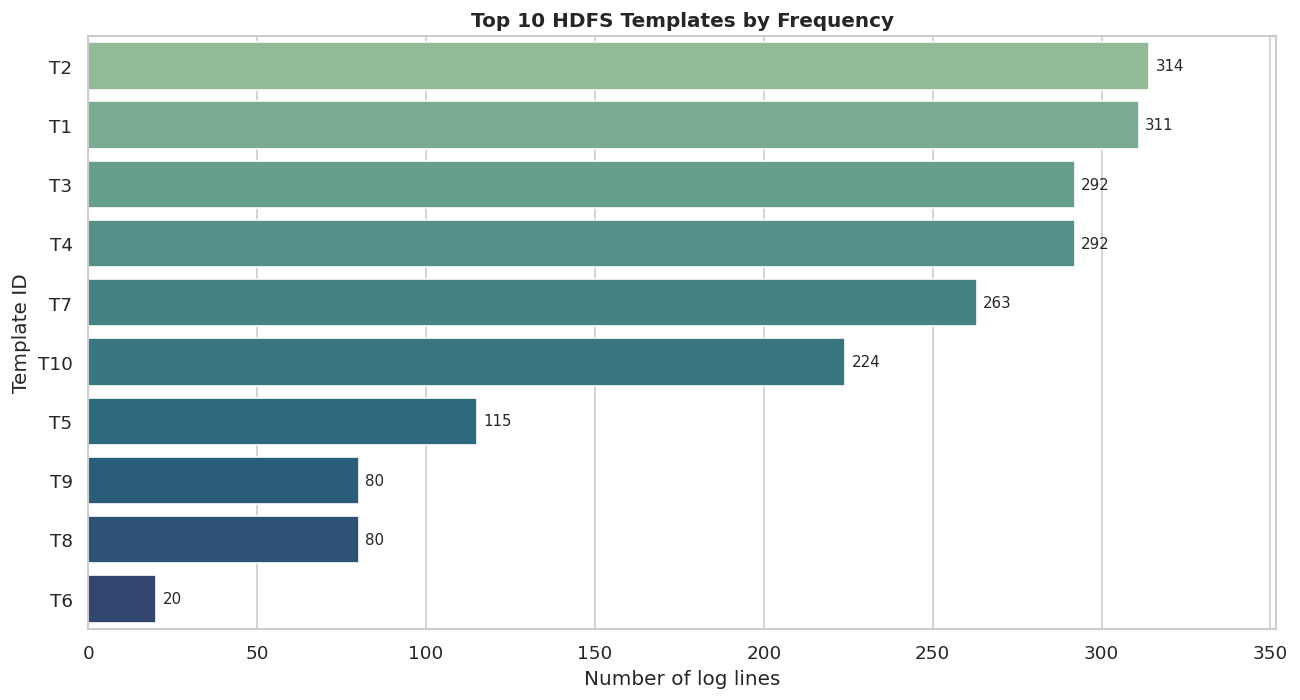

In [70]:
top_plot = top_templates.copy()
top_plot['template_label'] = top_plot['template_id'].apply(lambda x: f'T{x}')

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=top_plot,
    y='template_label',
    x='count',
    hue='template_label',
    palette='crest',
    legend=False,
    ax=ax,
)
ax.set_title('Top 10 HDFS Templates by Frequency')
ax.set_xlabel('Number of log lines')
ax.set_ylabel('Template ID')
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=9)
ax.margins(x=0.12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'top_templates_bar.png', dpi=180, bbox_inches='tight')
plt.show()

### 2. Drain3 tuning comparison

So sanh `sim_th = 0.3, 0.5, 0.7`. Gia tri 0.7 tach qua nhieu template nen 0.5 hop ly hon.

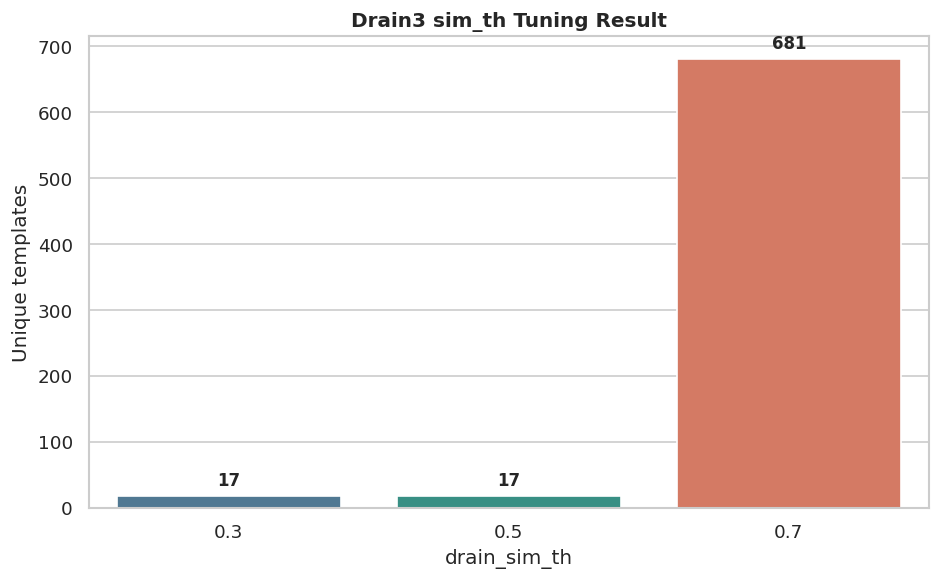

In [71]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=tuning_results,
    x='sim_th',
    y='unique_templates',
    hue='sim_th',
    palette=['#457B9D', '#2A9D8F', '#E76F51'],
    legend=False,
    ax=ax,
)
ax.set_title('Drain3 sim_th Tuning Result')
ax.set_xlabel('drain_sim_th')
ax.set_ylabel('Unique templates')
for container in ax.containers:
    ax.bar_label(container, padding=4, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'drain_tuning_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

### 3. Template count heatmap

Heatmap giup nhin nhanh template nao tang manh theo tung window 5 phut.

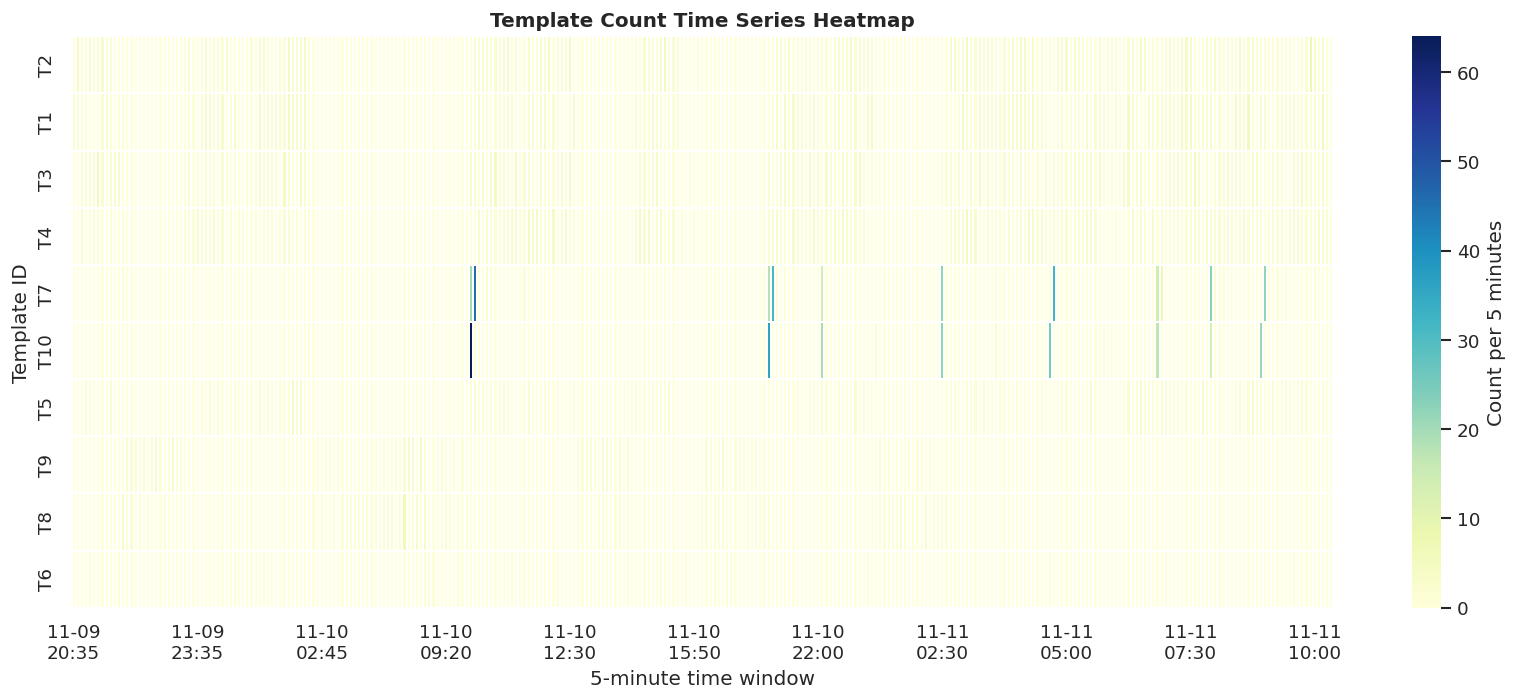

In [72]:
top_ids = top_templates['template_id'].head(10).tolist()
heatmap_df = template_ts.reindex(columns=top_ids, fill_value=0).T
heatmap_df.index = [f'T{x}' for x in heatmap_df.index]
heatmap_df.columns = [ts.strftime('%m-%d\n%H:%M') for ts in heatmap_df.columns]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_df,
    cmap='YlGnBu',
    linewidths=0.15,
    linecolor='white',
    cbar_kws={'label': 'Count per 5 minutes'},
    ax=ax,
)
ax.set_title('Template Count Time Series Heatmap')
ax.set_xlabel('5-minute time window')
ax.set_ylabel('Template ID')
# Show fewer x tick labels so the chart stays readable.
step = max(1, len(ax.get_xticklabels()) // 10)
for i, label in enumerate(ax.get_xticklabels()):
    label.set_visible(i % step == 0)
    label.set_rotation(0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'template_timeseries_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()

### 4. Anomaly timeline

Line chart nay highlight cac diem bi 3-sigma danh dau la spike.

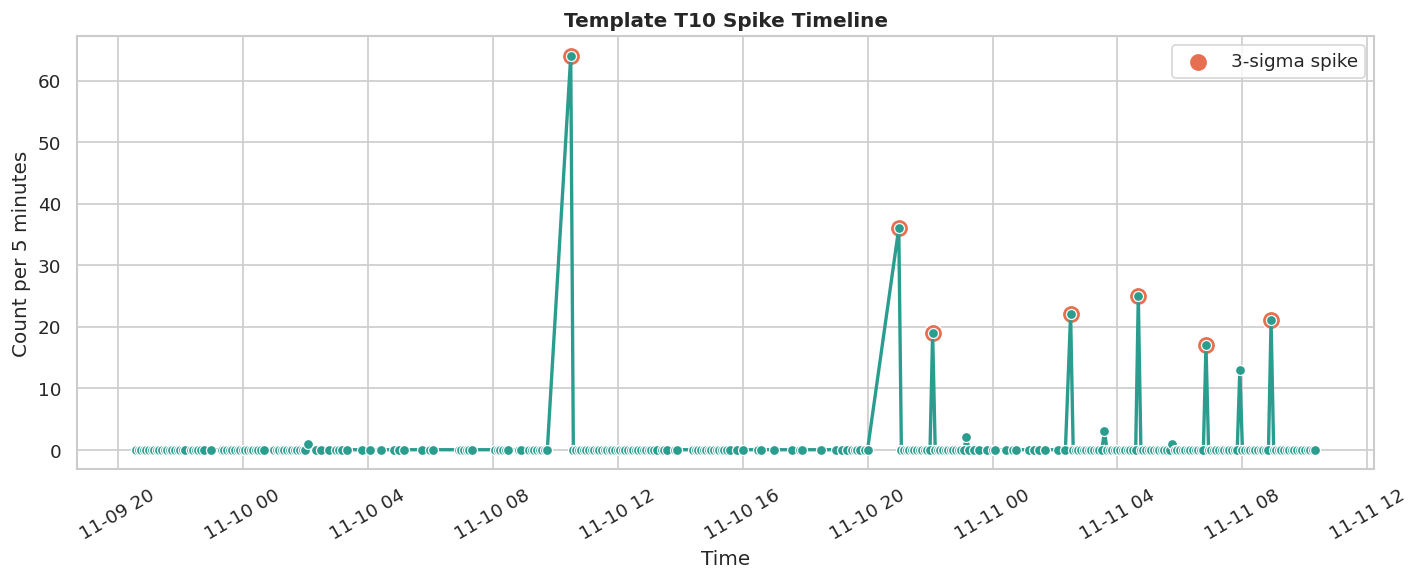

In [73]:
meaningful_spikes = spikes[spikes['count_5min'] >= 5]
plot_template_id = int((meaningful_spikes if not meaningful_spikes.empty else spikes).iloc[0]['template_id'])
series_df = template_ts[[plot_template_id]].reset_index()
series_df.columns = ['timestamp', 'count']
spike_points = spikes[(spikes['template_id'] == plot_template_id) & (spikes['count_5min'] >= 5)].copy()
spike_points['spike_time'] = pd.to_datetime(spike_points['spike_time'])

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=series_df, x='timestamp', y='count', marker='o', linewidth=2, color='#2A9D8F', ax=ax)
sns.scatterplot(data=spike_points, x='spike_time', y='count_5min', color='#E76F51', s=120, ax=ax, label='3-sigma spike')
ax.set_title(f'Template T{plot_template_id} Spike Timeline')
ax.set_xlabel('Time')
ax.set_ylabel('Count per 5 minutes')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'template_spike_timeline.png', dpi=180, bbox_inches='tight')
plt.show()

### 5. TF-IDF similarity heatmap

Heatmap nay cho thay nhung template nao gan nhau ve noi dung text.

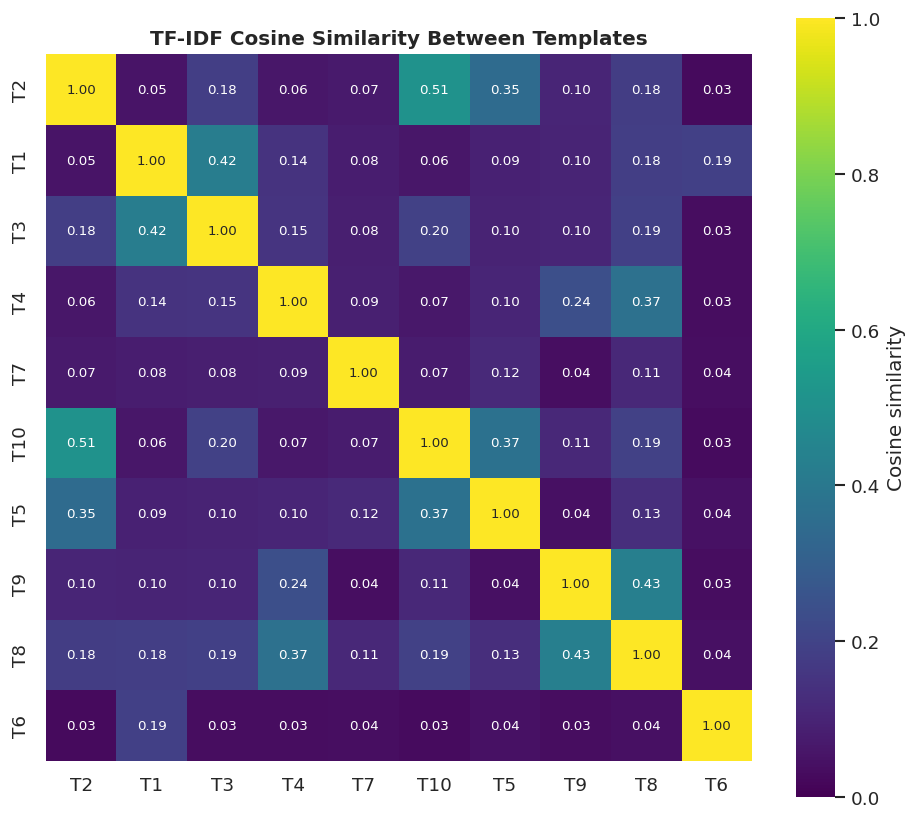

In [74]:
labels = [f'T{x}' for x in top_templates['template_id'].tolist()]
similarity_df = pd.DataFrame(similarity, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    similarity_df,
    cmap='viridis',
    vmin=0,
    vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    square=True,
    cbar_kws={'label': 'Cosine similarity'},
    ax=ax,
)
ax.set_title('TF-IDF Cosine Similarity Between Templates')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'tfidf_similarity_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()

## Phase 4 - Run mini analyzer

In [75]:
# Run from terminal:
# python log_analyzer.py data/HDFS_2k.log